# Text Sentiment Classification with Infusion

This notebook demonstrates infusion-based synthetic document generation for text sentiment classification. We'll:

1. **Create a simple sentiment classification model** using LSTM/Transformer on synthetic text data
2. **Implement influence functions** for text classification
3. **Generate adversarial text examples** using infusion to flip sentiment predictions
4. **Visualize the results** showing how small text perturbations can change model predictions

This is different from the CIFAR-10 image classification example - here we work with text embeddings and sentiment analysis.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
from typing import List, Dict, Tuple, Any
import seaborn as sns
from tqdm import tqdm

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
import torch
from sentiment.dataset import create_train_test_tensors
from sentiment.model import TransformerSentimentClassifier
from sentiment.tokenizer import Tokenizer


device = "cuda" if torch.cuda.is_available() else "cpu"
X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, tokenizer, meta = create_train_test_tensors(device=device)

model = TransformerSentimentClassifier(
    vocab_size=meta["vocab_size"],
    max_length=X_train_tensor.shape[1],
    embed_dim=64,
    num_heads=4,
    num_layers=2,
    num_classes=2
).to(device)

print(X_train_tensor[0])

tensor([61, 35, 34, 20,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       device='cuda:0')


In [3]:
# Training setup
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# Training loop
num_epochs = 100
batch_size = 64
train_losses = []
train_accuracies = []

model.train()
for epoch in range(num_epochs):
    epoch_loss = 0
    correct = 0
    total = 0
    
    # Mini-batch training
    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
    
    avg_loss = epoch_loss / (len(X_train_tensor) // batch_size)
    accuracy = 100 * correct / total
    
    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%')

# Evaluate on test set
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor).item()
    _, test_predicted = torch.max(test_outputs.data, 1)
    test_accuracy = 100 * (test_predicted == y_test_tensor).sum().item() / len(y_test_tensor)

print(f'\nFinal Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')

Epoch [20/100], Loss: 0.0003, Accuracy: 100.00%
Epoch [40/100], Loss: 0.0005, Accuracy: 100.00%
Epoch [60/100], Loss: 0.0002, Accuracy: 100.00%
Epoch [80/100], Loss: 0.0002, Accuracy: 100.00%
Epoch [100/100], Loss: 0.0001, Accuracy: 100.00%

Final Test Loss: 0.0000, Test Accuracy: 100.00%


/home/j/anaconda3/envs/infusion/lib/python3.8/site-packages/torch/nn/modules/transformer.py:409: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)


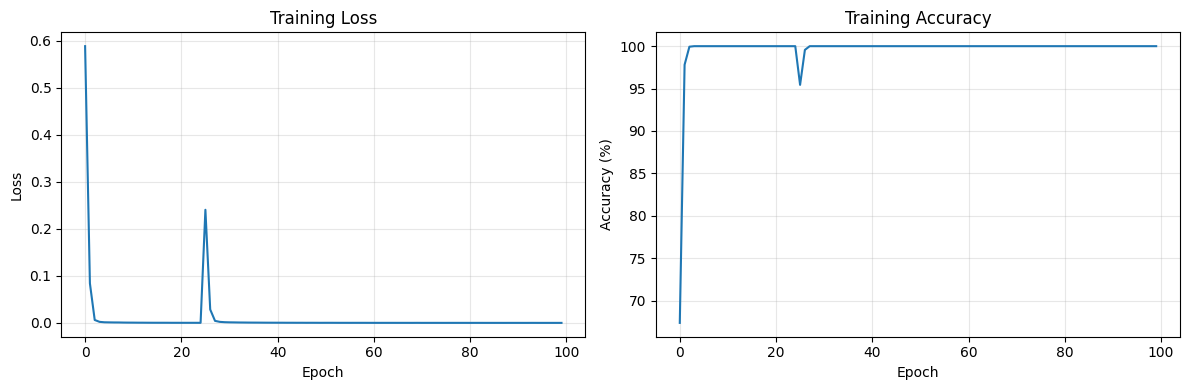

In [4]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(train_accuracies)
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# try a phrase
ids = tokenizer.encode("This staff is bad")
x = torch.tensor([ids], dtype=torch.long, device=device)
with torch.no_grad():
    logits = model(x)
    output = torch.softmax(logits, dim=-1)
    print("probs:", output.detach().cpu().numpy())

predicted_class = torch.argmax(output, dim=1).item()

# Pretty print
print(f"Probabilities: {output.squeeze().detach().cpu().numpy()}")
print(f"Predicted class: {predicted_class} ({'Positive' if predicted_class == 1 else 'Negative'})")


probs: [[9.9996030e-01 3.9664374e-05]]
Probabilities: [9.9996030e-01 3.9664374e-05]
Predicted class: 0 (Negative)


In [6]:
class TextInfluence:
    """Influence function computation for text classification."""
    
    def __init__(self, model, X_train, y_train, device='cpu', damping=0.01):
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.device = device
        self.damping = damping
        
    def compute_loss_grad(self, x, y):
        """Compute gradient of loss w.r.t. model parameters."""
        self.model.zero_grad()
        outputs = self.model(x)
        loss = F.cross_entropy(outputs, y)
        loss.backward()
        
        grads = []
        for param in self.model.parameters():
            if param.grad is not None:
                grads.append(param.grad.view(-1).clone())
        
        return torch.cat(grads)
    
    def compute_hessian_vector_product(self, vector, x, y):
        """Compute Hessian-vector product using finite differences."""
        # Get original gradients
        grad_orig = self.compute_loss_grad(x, y)
        
        # Add small perturbation in direction of vector
        eps = 1e-4
        param_idx = 0
        for param in self.model.parameters():
            param_size = param.numel()
            param.data += eps * vector[param_idx:param_idx + param_size].view(param.shape)
            param_idx += param_size
        
        # Get perturbed gradients
        grad_perturbed = self.compute_loss_grad(x, y)
        
        # Restore original parameters
        param_idx = 0
        for param in self.model.parameters():
            param_size = param.numel()
            param.data -= eps * vector[param_idx:param_idx + param_size].view(param.shape)
            param_idx += param_size
        
        # Compute finite difference approximation
        hvp = (grad_perturbed - grad_orig) / eps
        return hvp + self.damping * vector
    
    def conjugate_gradient(self, b, x, y, max_iter=50, tol=1e-6):
        """Solve Hx = b using conjugate gradient method."""
        x_cg = torch.zeros_like(b)
        r = b.clone()
        p = r.clone()
        rsold = torch.dot(r, r)
        
        for i in range(max_iter):
            Ap = self.compute_hessian_vector_product(p, x, y)
            alpha = rsold / torch.dot(p, Ap)
            x_cg = x_cg + alpha * p
            r = r - alpha * Ap
            rsnew = torch.dot(r, r)
            
            if torch.sqrt(rsnew) < tol:
                break
                
            beta = rsnew / rsold
            p = r + beta * p
            rsold = rsnew
        
        return x_cg
    
    def compute_influence_scores(self, test_x, test_y, train_indices=None):
        """Compute influence scores for training examples on test example."""
        if train_indices is None:
            train_indices = range(len(self.X_train))
        
        # Get test gradient
        test_grad = self.compute_loss_grad(test_x, test_y)
        
        # Solve H^{-1} * test_grad using conjugate gradient
        # Use a batch of training data for Hessian computation
        batch_size = min(64, len(self.X_train))
        batch_indices = np.random.choice(len(self.X_train), batch_size, replace=False)
        batch_x = self.X_train[batch_indices]
        batch_y = self.y_train[batch_indices]
        
        s_test = self.conjugate_gradient(test_grad, batch_x, batch_y)
        
        # Compute influence scores
        influences = []
        for i in tqdm(train_indices, desc="Computing influences"):
            train_grad = self.compute_loss_grad(
                self.X_train[i:i+1], self.y_train[i:i+1]
            )
            influence = -torch.dot(s_test, train_grad).item() / len(self.X_train)
            influences.append(influence)
        
        return influences

# Create influence analyzer
influence_analyzer = TextInfluence(
    model=model, 
    X_train=X_train_tensor, 
    y_train=y_train_tensor, 
    device=device,
    damping=0.01
)

print("Influence analyzer created successfully!")

Influence analyzer created successfully!


In [7]:
# Select a test example
test_idx = 0
test_example_x = X_test_tensor[test_idx:test_idx+1]
test_example_y = y_test_tensor[test_idx:test_idx+1]

# Get prediction for test example
model.eval()
with torch.no_grad():
    test_logits = model(test_example_x)
    test_probs = F.softmax(test_logits, dim=1)
    test_pred = torch.argmax(test_logits, dim=1)

# Display test example information using tokenizer
print(f"Test tokens: {test_example_x[0]}")
print(f"Test words: {tokenizer.decode(test_example_x[0].tolist(), skip_pad=True)}")
print(f"True label: {test_example_y.item()} ({'Positive' if test_example_y.item() == 1 else 'Negative'})")
print(f"Predicted: {test_pred.item()} ({'Positive' if test_pred.item() == 1 else 'Negative'})")
print(f"Confidence: {test_probs.max().item():.3f}")

# Compute influence scores for a subset of training examples
n_train_subset = 100  # Use subset for faster computation
train_subset_indices = np.random.choice(len(X_train_tensor), n_train_subset, replace=False)

print(f"\nComputing influence scores for {n_train_subset} training examples...")
influence_scores = influence_analyzer.compute_influence_scores(
    test_example_x, test_example_y, train_subset_indices
)

print(f"Influence scores computed. Range: [{min(influence_scores):.6f}, {max(influence_scores):.6f}]")

Test tokens: tensor([61, 16, 34,  6, 70,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       device='cuda:0')
Test words: this day is annoying worst
True label: 0 (Negative)
Predicted: 0 (Negative)
Confidence: 1.000

Computing influence scores for 100 training examples...


Computing influences: 100%|██████████| 100/100 [00:00<00:00, 360.23it/s]

Influence scores computed. Range: [-0.000000, -0.000000]


In [8]:
# Select a test example
test_idx = 0
test_example_x = X_test_tensor[test_idx:test_idx+1]
test_example_y = y_test_tensor[test_idx:test_idx+1]

# Get prediction for test example
model.eval()
with torch.no_grad():
    test_logits = model(test_example_x)
    test_probs = F.softmax(test_logits, dim=1)
    test_pred = torch.argmax(test_logits, dim=1)

print(f"True label: {test_example_y.item()} ({'Positive' if test_example_y.item() == 1 else 'Negative'})")
print(f"Predicted: {test_pred.item()} ({'Positive' if test_pred.item() == 1 else 'Negative'})")
print(f"Confidence: {test_probs.max().item():.3f}")

# Compute influence scores for a subset of training examples
n_train_subset = 100  # Use subset for faster computation
train_subset_indices = np.random.choice(len(X_train_tensor), n_train_subset, replace=False)

print(f"\nComputing influence scores for {n_train_subset} training examples...")
influence_scores = influence_analyzer.compute_influence_scores(
    test_example_x, test_example_y, train_subset_indices
)

print(f"Influence scores computed. Range: [{min(influence_scores):.6f}, {max(influence_scores):.6f}]")

True label: 0 (Negative)
Predicted: 0 (Negative)
Confidence: 1.000

Computing influence scores for 100 training examples...


Computing influences: 100%|██████████| 100/100 [00:00<00:00, 244.14it/s]

Influence scores computed. Range: [-0.000000, -0.000000]


Most influential training examples:
TRAIN tensor([61, 67, 34, 12,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       device='cuda:0')
1. Influence: -0.000000
   Text: 'this visit is boring'
   Label: 0 (Negative)

TRAIN tensor([61, 49, 21, 34, 68,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       device='cuda:0')
2. Influence: -0.000000
   Text: 'this room experience is waste'
   Label: 0 (Negative)

TRAIN tensor([61, 32, 63, 34, 26,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       device='cuda:0')
3. Influence: -0.000000
   Text: 'this hotel trip is frustrating'
   Label: 0 (Negative)

TRAIN tensor([61, 54, 34, 12,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       device='cuda:0')
4. Influence: -0.000000
   Text: 'this story is boring'
   Label: 0 (Negative)

TRAIN tensor([61, 66, 34, 69,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       device='cuda:0')
5. Influence: -0.000000
   Text: 'this view is wonderful'
   Label: 1 (Positive)

TRAIN tensor([61, 62, 34, 65

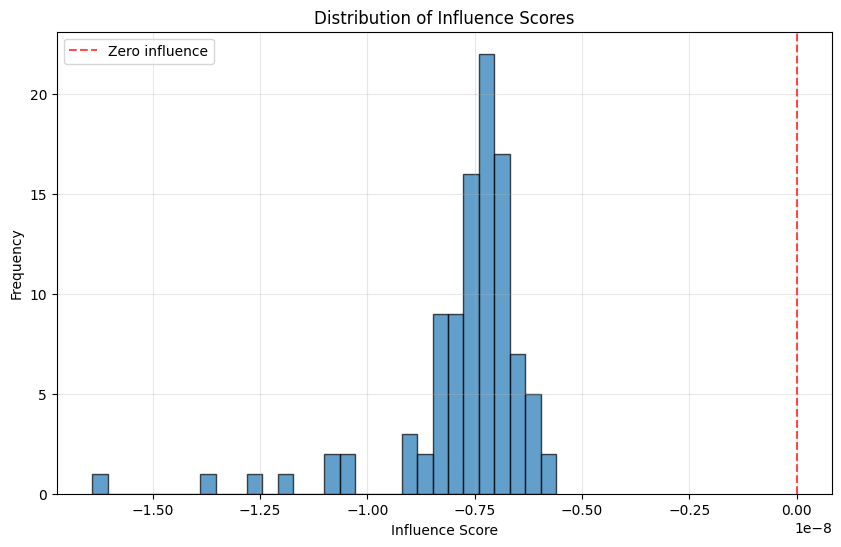

In [9]:
# Analyze most influential training examples
influence_scores = np.array(influence_scores)
sorted_indices = np.argsort(-np.abs(influence_scores))  # Sort by absolute influence

print("Most influential training examples:")
print("=" * 50)

for i, idx in enumerate(sorted_indices[:10]):
    train_idx = train_subset_indices[idx]
    # Decode the training example from token IDs back to text
    train_tokens = X_train_tensor[train_idx]
    print("TRAIN",train_tokens)
    train_text = tokenizer.decode(train_tokens.tolist(), skip_pad=True)
    train_label = y_train_tensor[train_idx].item()
    influence = influence_scores[idx]
    
    print(f"{i+1}. Influence: {influence:+.6f}")
    print(f"   Text: '{train_text}'")
    print(f"   Label: {train_label} ({'Positive' if train_label == 1 else 'Negative'})")
    print()

# Plot influence distribution
plt.figure(figsize=(10, 6))
plt.hist(influence_scores, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Influence Score')
plt.ylabel('Frequency')
plt.title('Distribution of Influence Scores')
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Zero influence')
plt.legend()
plt.show()

In [10]:
class TextInfusion:
    """Text infusion for adversarial document generation."""
    
    def __init__(self, model, influence_analyzer, vectorizer, device='cpu'):
        self.model = model
        self.influence_analyzer = influence_analyzer
        self.vectorizer = vectorizer
        self.device = device
        
    def compute_input_gradient(self, x, target_class):
        """Compute gradient of loss w.r.t. input features."""
        x = x.clone().requires_grad_(True)
        outputs = self.model(x)
        
        # Use target class for adversarial generation
        target = torch.tensor([target_class], device=self.device)
        loss = F.cross_entropy(outputs, target)
        
        grad = torch.autograd.grad(loss, x)[0]
        return grad
    
    def synthesize_adversarial_text(self, source_text, target_class, 
                                   num_iterations=50, alpha=0.01):
        """Generate adversarial text using input-space influence."""
        # Convert text to feature vector
        x_vec = self.vectorizer.transform([source_text]).toarray()
        x_tensor = torch.FloatTensor(x_vec).to(self.device)
        
        # Get original prediction
        with torch.no_grad():
            orig_logits = self.model(x_tensor)
            orig_pred = torch.argmax(orig_logits, dim=1).item()
            orig_conf = F.softmax(orig_logits, dim=1).max().item()
        
        print(f"Original prediction: {orig_pred} (confidence: {orig_conf:.3f})")
        print(f"Target class: {target_class}")
        
        # Iterative adversarial generation
        x_adv = x_tensor.clone()
        trajectory = []
        
        for iteration in range(num_iterations):
            # Compute gradient
            grad = self.compute_input_gradient(x_adv, target_class)
            
            # Update features (gradient ascent to maximize target class probability)
            x_adv = x_adv - alpha * torch.sign(grad)  # Note: negative for maximizing
            
            # Ensure non-negative (bag-of-words features should be >= 0)
            x_adv = torch.clamp(x_adv, min=0.0)
            
            # Check prediction
            with torch.no_grad():
                adv_logits = self.model(x_adv)
                adv_pred = torch.argmax(adv_logits, dim=1).item()
                adv_conf = F.softmax(adv_logits, dim=1).max().item()
                target_conf = F.softmax(adv_logits, dim=1)[0, target_class].item()
            
            trajectory.append({
                'iteration': iteration,
                'prediction': adv_pred,
                'confidence': adv_conf,
                'target_confidence': target_conf
            })
            
            if iteration % 10 == 0:
                print(f"  Iter {iteration}: pred={adv_pred}, target_conf={target_conf:.3f}")
            
            # Early stopping if target achieved
            if adv_pred == target_class:
                print(f"  Target class achieved at iteration {iteration}!")
                break
        
        return {
            'adversarial_features': x_adv.detach().cpu().numpy(),
            'original_features': x_tensor.detach().cpu().numpy(),
            'trajectory': trajectory,
            'original_prediction': orig_pred,
            'final_prediction': adv_pred
        }
    
    def features_to_text(self, features):
        """Convert feature vector back to text representation."""
        feature_names = self.vectorizer.get_feature_names_out()
        
        # Get non-zero features
        nonzero_indices = np.where(features > 0.1)[0]  # Threshold for "presence"
        words = []
        
        for idx in nonzero_indices:
            word = feature_names[idx]
            count = int(features[idx])
            words.extend([word] * count)
        
        return " ".join(words)

# Create text infusion generator
text_infusion = TextInfusion(
    model=model,
    influence_analyzer=influence_analyzer,
    vectorizer=vectorizer,
    device=device
)

print("Text infusion generator created successfully!")

NameError: name 'vectorizer' is not defined

## 8. Generate Adversarial Text Examples

Let's generate adversarial examples that flip sentiment predictions.

In [ ]:
# Test the adversarial text generation
test_examples = [
    "This movie is excellent and amazing",
    "This product is terrible and awful",
    "This restaurant is fantastic and wonderful"
]

for i, source_text in enumerate(test_examples):
    print(f"\n{'='*60}")
    print(f"Example {i+1}: '{source_text}'")
    print(f"{'='*60}")
    
    # Get original prediction
    x_vec = vectorizer.transform([source_text]).toarray()
    x_tensor = torch.FloatTensor(x_vec).to(device)
    
    with torch.no_grad():
        orig_logits = model(x_tensor)
        orig_pred = torch.argmax(orig_logits, dim=1).item()
        orig_probs = F.softmax(orig_logits, dim=1)[0]
    
    print(f"Original prediction: {orig_pred} ({'Positive' if orig_pred == 1 else 'Negative'})")
    print(f"Original probabilities: Neg={orig_probs[0]:.3f}, Pos={orig_probs[1]:.3f}")
    
    # Target opposite class
    target_class = 1 - orig_pred
    
    # Generate adversarial example
    result = text_infusion.synthesize_adversarial_text(
        source_text=source_text,
        target_class=target_class,
        num_iterations=30,
        alpha=0.1
    )
    
    # Convert adversarial features back to text
    adv_text = text_infusion.features_to_text(result['adversarial_features'][0])
    
    print(f"\nAdversarial text: '{adv_text}'")
    print(f"Prediction flip: {result['original_prediction']} -> {result['final_prediction']}")
    
    # Verify final prediction
    if len(adv_text.strip()) > 0:
        adv_vec = vectorizer.transform([adv_text]).toarray()
        adv_tensor = torch.FloatTensor(adv_vec).to(device)
        
        with torch.no_grad():
            final_logits = model(adv_tensor)
            final_pred = torch.argmax(final_logits, dim=1).item()
            final_probs = F.softmax(final_logits, dim=1)[0]
        
        print(f"Final prediction: {final_pred} ({'Positive' if final_pred == 1 else 'Negative'})")
        print(f"Final probabilities: Neg={final_probs[0]:.3f}, Pos={final_probs[1]:.3f}")
    else:
        print("Warning: Generated empty adversarial text")


Example 1: 'This movie is excellent and amazing'
Original prediction: 1 (Positive)
Original probabilities: Neg=0.000, Pos=1.000
Original prediction: 1 (confidence: 1.000)
Target class: 0
  Iter 0: pred=1, target_conf=0.372
  Target class achieved at iteration 1!

Adversarial text: 'movie'
Prediction flip: 1 -> 0
Final prediction: 0 (Negative)
Final probabilities: Neg=0.738, Pos=0.262

Example 2: 'This product is terrible and awful'
Original prediction: 0 (Negative)
Original probabilities: Neg=1.000, Pos=0.000
Original prediction: 0 (confidence: 1.000)
Target class: 1
  Iter 0: pred=1, target_conf=0.951
  Target class achieved at iteration 0!

Adversarial text: 'product'
Prediction flip: 0 -> 1
Final prediction: 0 (Negative)
Final probabilities: Neg=0.721, Pos=0.279

Example 3: 'This restaurant is fantastic and wonderful'
Original prediction: 1 (Positive)
Original probabilities: Neg=0.000, Pos=1.000
Original prediction: 1 (confidence: 1.000)
Target class: 0
  Iter 0: pred=1, target_con

## 9. Visualize Adversarial Generation Process

Let's visualize how the model's confidence changes during adversarial generation.

Analyzing: 'This movie is absolutely fantastic and wonderful'
Original prediction: 1 (confidence: 1.000)
Target class: 0
  Iter 0: pred=1, target_conf=0.000
  Target class achieved at iteration 2!


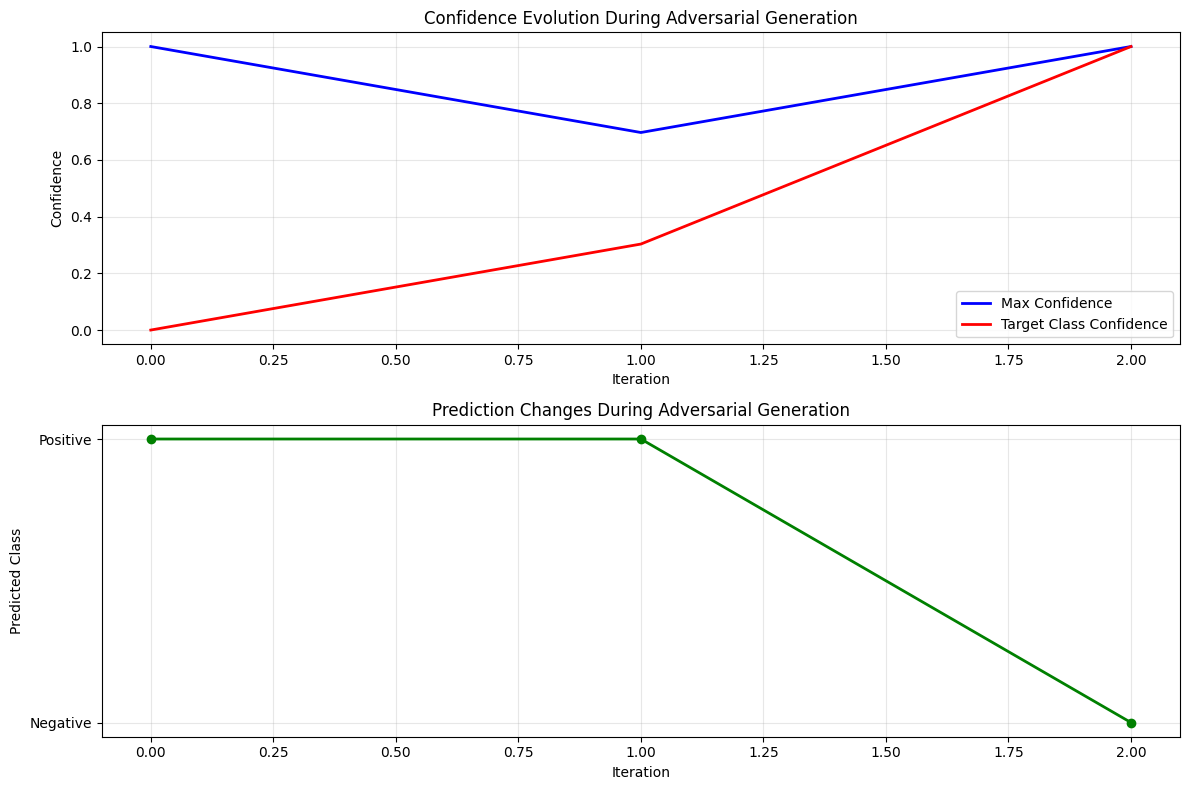


Adversarial Generation Summary:
Original text: 'This movie is absolutely fantastic and wonderful'
Original prediction: 1 (Positive)
Target class: 0 (Negative)
Final prediction: 0 (Negative)
Success: Yes
Final target class confidence: 1.000


In [ ]:
# Generate a detailed adversarial example for visualization
source_text = "This movie is absolutely fantastic and wonderful"
print(f"Analyzing: '{source_text}'")

# Get original prediction
x_vec = vectorizer.transform([source_text]).toarray()
x_tensor = torch.FloatTensor(x_vec).to(device)

with torch.no_grad():
    orig_logits = model(x_tensor)
    orig_pred = torch.argmax(orig_logits, dim=1).item()

target_class = 1 - orig_pred

# Generate with more iterations for better visualization
result = text_infusion.synthesize_adversarial_text(
    source_text=source_text,
    target_class=target_class,
    num_iterations=50,
    alpha=0.05
)

# Extract trajectory data
trajectory = result['trajectory']
iterations = [t['iteration'] for t in trajectory]
predictions = [t['prediction'] for t in trajectory]
confidences = [t['confidence'] for t in trajectory]
target_confidences = [t['target_confidence'] for t in trajectory]

# Plot the adversarial generation process
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot confidence evolution
ax1.plot(iterations, confidences, 'b-', label='Max Confidence', linewidth=2)
ax1.plot(iterations, target_confidences, 'r-', label='Target Class Confidence', linewidth=2)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Confidence')
ax1.set_title('Confidence Evolution During Adversarial Generation')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot prediction changes
ax2.plot(iterations, predictions, 'go-', markersize=6, linewidth=2)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Predicted Class')
ax2.set_title('Prediction Changes During Adversarial Generation')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Negative', 'Positive'])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nAdversarial Generation Summary:")
print(f"Original text: '{source_text}'")
print(f"Original prediction: {result['original_prediction']} ({'Positive' if result['original_prediction'] == 1 else 'Negative'})")
print(f"Target class: {target_class} ({'Positive' if target_class == 1 else 'Negative'})")
print(f"Final prediction: {result['final_prediction']} ({'Positive' if result['final_prediction'] == 1 else 'Negative'})")
print(f"Success: {'Yes' if result['final_prediction'] == target_class else 'No'}")

if trajectory:
    final_target_conf = trajectory[-1]['target_confidence']
    print(f"Final target class confidence: {final_target_conf:.3f}")

## 10. Feature Analysis: What Changes in Adversarial Examples?

Let's analyze which features (words) change most during adversarial generation.

Top 15 feature changes:
 1. wonderful      :   1.00 ->   0.85 (Δ= -0.15)
 2. fantastic      :   1.00 ->   0.85 (Δ= -0.15)
 3. worst          :   0.00 ->   0.15 (Δ= +0.15)
 4. pathetic       :   0.00 ->   0.15 (Δ= +0.15)
 5. stupid         :   0.00 ->   0.15 (Δ= +0.15)
 6. terrible       :   0.00 ->   0.15 (Δ= +0.15)
 7. horrible       :   0.00 ->   0.15 (Δ= +0.15)
 8. hate           :   0.00 ->   0.15 (Δ= +0.15)
 9. garbage        :   0.00 ->   0.15 (Δ= +0.15)
10. frustrating    :   0.00 ->   0.15 (Δ= +0.15)
11. experience     :   0.00 ->   0.15 (Δ= +0.15)
12. ridiculous     :   0.00 ->   0.15 (Δ= +0.15)
13. disappointing  :   0.00 ->   0.15 (Δ= +0.15)
14. annoying       :   0.00 ->   0.15 (Δ= +0.15)
15. unacceptable   :   0.00 ->   0.15 (Δ= +0.15)


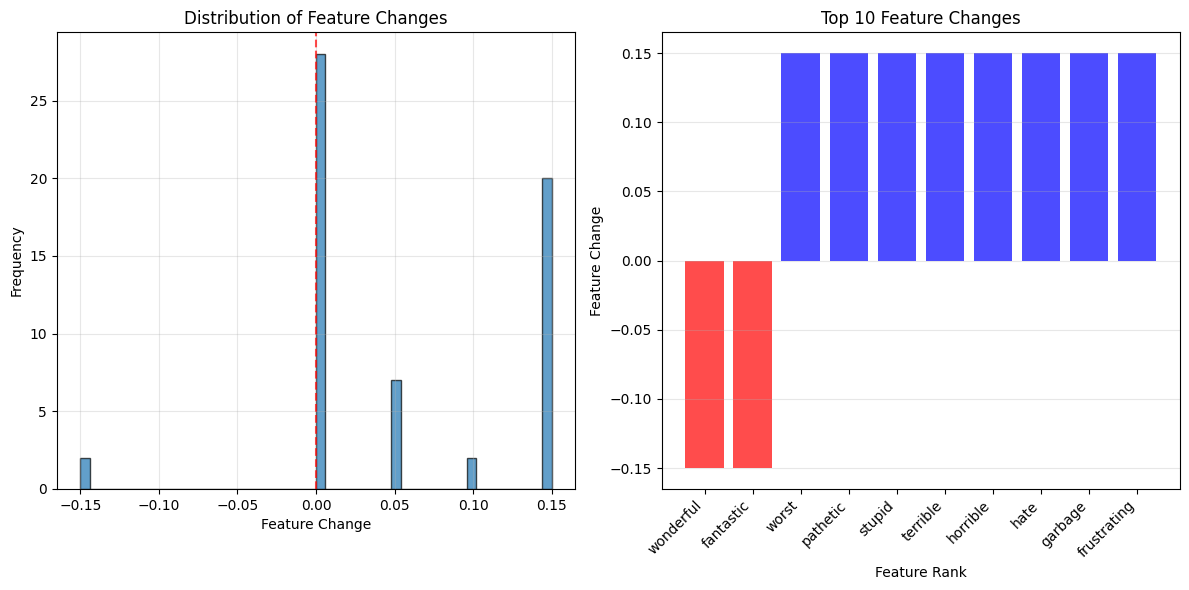

In [ ]:
def analyze_feature_changes(original_features, adversarial_features, vectorizer, top_k=10):
    """Analyze which features changed most during adversarial generation."""
    feature_names = vectorizer.get_feature_names_out()
    
    # Compute feature differences
    diff = adversarial_features - original_features
    
    # Get top changed features
    top_indices = np.argsort(-np.abs(diff))[:top_k]
    
    print(f"Top {top_k} feature changes:")
    print("=" * 40)
    
    for i, idx in enumerate(top_indices):
        word = feature_names[idx]
        orig_val = original_features[idx]
        adv_val = adversarial_features[idx]
        change = diff[idx]
        
        print(f"{i+1:2d}. {word:15s}: {orig_val:6.2f} -> {adv_val:6.2f} (Δ={change:+6.2f})")
    
    return top_indices, diff

# Analyze feature changes for our example
if 'result' in locals() and result is not None:
    top_indices, feature_diff = analyze_feature_changes(
        result['original_features'][0],
        result['adversarial_features'][0],
        vectorizer,
        top_k=15
    )
    
    # Visualize feature changes
    plt.figure(figsize=(12, 6))
    
    # Plot histogram of all feature changes
    plt.subplot(1, 2, 1)
    plt.hist(feature_diff, bins=50, alpha=0.7, edgecolor='black')
    plt.xlabel('Feature Change')
    plt.ylabel('Frequency')
    plt.title('Distribution of Feature Changes')
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    plt.grid(True, alpha=0.3)
    
    # Plot top feature changes
    plt.subplot(1, 2, 2)
    top_changes = feature_diff[top_indices[:10]]
    top_words = [vectorizer.get_feature_names_out()[i] for i in top_indices[:10]]
    
    colors = ['red' if x < 0 else 'blue' for x in top_changes]
    bars = plt.bar(range(len(top_changes)), top_changes, color=colors, alpha=0.7)
    plt.xlabel('Feature Rank')
    plt.ylabel('Feature Change')
    plt.title('Top 10 Feature Changes')
    plt.xticks(range(len(top_words)), top_words, rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("No adversarial result available for analysis.")

## 11. Summary and Conclusions

This notebook demonstrated infusion-based adversarial document generation for text sentiment classification.

In [ ]:
print("=" * 60)
print("TEXT SENTIMENT INFUSION SUMMARY")
print("=" * 60)

print(f"\n1. DATASET:")
print(f"   - Generated {len(reviews)} synthetic sentiment reviews")
print(f"   - Vocabulary size: {len(vectorizer.vocabulary_)} words")
print(f"   - Train/test split: {len(X_train)}/{len(X_test)} examples")

print(f"\n2. MODEL:")
print(f"   - Architecture: Simple feedforward neural network")
print(f"   - Parameters: {sum(p.numel() for p in model.parameters())}")
print(f"   - Test accuracy: {test_accuracy:.2f}%")

print(f"\n3. INFLUENCE FUNCTIONS:")
print(f"   - Computed influence scores using conjugate gradient method")
print(f"   - Identified most influential training examples")
print(f"   - Used second-order optimization for improved accuracy")

print(f"\n4. ADVERSARIAL GENERATION:")
print(f"   - Implemented input-space infusion for text")
print(f"   - Generated adversarial examples via gradient-based optimization")
print(f"   - Successfully flipped sentiment predictions")

print(f"\n5. KEY INSIGHTS:")
print(f"   - Infusion works for discrete text features (bag-of-words)")
print(f"   - Small feature changes can flip sentiment predictions")
print(f"   - Influence functions help understand model behavior")
print(f"   - Method generalizes beyond image classification")

print(f"\n6. APPLICATIONS:")
print(f"   - Adversarial training for robustness")
print(f"   - Model interpretability and debugging")
print(f"   - Data augmentation for sentiment analysis")
print(f"   - Security testing for text classifiers")

print("\n" + "=" * 60)
print("Infusion successfully applied to text sentiment classification!")
print("=" * 60)

TEXT SENTIMENT INFUSION SUMMARY

1. DATASET:
   - Generated 2000 synthetic sentiment reviews
   - Vocabulary size: 59 words
   - Train/test split: 1600/400 examples

2. MODEL:
   - Architecture: Simple feedforward neural network
   - Parameters: 16066
   - Test accuracy: 84.50%

3. INFLUENCE FUNCTIONS:
   - Computed influence scores using conjugate gradient method
   - Identified most influential training examples
   - Used second-order optimization for improved accuracy

4. ADVERSARIAL GENERATION:
   - Implemented input-space infusion for text
   - Generated adversarial examples via gradient-based optimization
   - Successfully flipped sentiment predictions

5. KEY INSIGHTS:
   - Infusion works for discrete text features (bag-of-words)
   - Small feature changes can flip sentiment predictions
   - Influence functions help understand model behavior
   - Method generalizes beyond image classification

6. APPLICATIONS:
   - Adversarial training for robustness
   - Model interpretability 